# VGG 16 

- used by many application. Developed in 2014
- It has 16x convolutional layers
- it has uniform architecture
- The bad thing by VGG16 is the huge number of parameters, 138 million parameters


## architecture
- Conv1
- Conv1
- Pooling
- Conv2
- Conv2
- Pooling
- Conv3
- Conv3
- Conv3
- Pooling
- Conv4
- Conv4
- Conv4
- Pooling
- Conv5
- Conv5
- Conv5
- Pooling
- FC
- FC
- FC
- Output

In [1]:
import keras

from keras.models import Sequential
from keras.layers import Conv2D  # Images are 2D -> Conv2D , if we work with videos --> Conv3D
from keras.layers import MaxPool2D  
from keras.layers import Flatten # converting 2D arrays into a signle long linear vector
from keras.layers import Dense   # fully connected layer 
from keras.applications.vgg16 import preprocess_input
from keras.utils import load_img, img_to_array
from tensorflow.keras.preprocessing.image import ImageDataGenerator
# to rescale image, rotate, zoom, flip. etc
from keras.applications.vgg16 import VGG16, preprocess_input

import tensorflow as tf
import numpy as np
import random


## extra, seeds
para no volver loco el experimento

In [2]:
tf.random.set_seed(42)
np.random.seed(42)
random.seed(42)

In [3]:
# For training Data --> Rescale
tr_data = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.1,
    horizontal_flip=True
)
train_data = tr_data.flow_from_directory(
    directory="./dataset/training",
    target_size=(224,224),
    class_mode="binary"
)

ts_data = ImageDataGenerator(preprocessing_function=preprocess_input)
test_data = ts_data.flow_from_directory(
    directory="./dataset/testing",
    target_size=(224,224),
    class_mode="binary",
    shuffle=False
)
# For test Data --> Rescale


Found 6 images belonging to 2 classes.
Found 4 images belonging to 2 classes.


In [4]:
# Get Instance of VGG16 model
# https://keras.io/api/applications/vgg/#vgg16-function
# include_top: whether to include the 3 fully-connected layers at the top of the network.


VGG = VGG16(input_shape=(224,224,3), include_top=False, weights="imagenet")

# Dont train the whole layers, just train the last two layers
VGG.trainable = False 



In [5]:
model = keras.Sequential(
    [
    VGG,
    keras.layers.GlobalAveragePooling2D(),
    keras.layers.Dense(128, activation="relu"),
    keras.layers.Dropout(0.3),
    keras.layers.Dense(1, activation="sigmoid")
    ]
)

model.compile(keras.optimizers.Adam(learning_rate=1e-4), loss="binary_crossentropy", metrics=["accuracy"])


In [6]:
# Fit the model
hist = model.fit(train_data, validation_data = test_data, epochs = 15)

Epoch 1/15
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step - accuracy: 0.5000 - loss: 5.1167 - val_accuracy: 0.5000 - val_loss: 3.7555
Epoch 2/15
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 657ms/step - accuracy: 0.5000 - loss: 3.1342 - val_accuracy: 0.5000 - val_loss: 3.3087
Epoch 3/15
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 671ms/step - accuracy: 0.6667 - loss: 4.5359 - val_accuracy: 0.5000 - val_loss: 2.8927
Epoch 4/15
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 656ms/step - accuracy: 0.5000 - loss: 2.7714 - val_accuracy: 0.5000 - val_loss: 2.5314
Epoch 5/15
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 691ms/step - accuracy: 0.1667 - loss: 5.3552 - val_accuracy: 0.7500 - val_loss: 2.2903
Epoch 6/15
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 666ms/step - accuracy: 0.5000 - loss: 4.2309 - val_accuracy: 0.7500 - val_loss: 2.1236
Epoch 7/15
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 635ms/step - accuracy: 0.5000 - loss: 5.0275 - val_accuracy: 0.7500 - val_loss: 1.9908
Epoch 8/15
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 645ms/step - accuracy: 0.3333 - loss: 4.3882 - val_accuracy: 0.5000 - val_loss: 1.

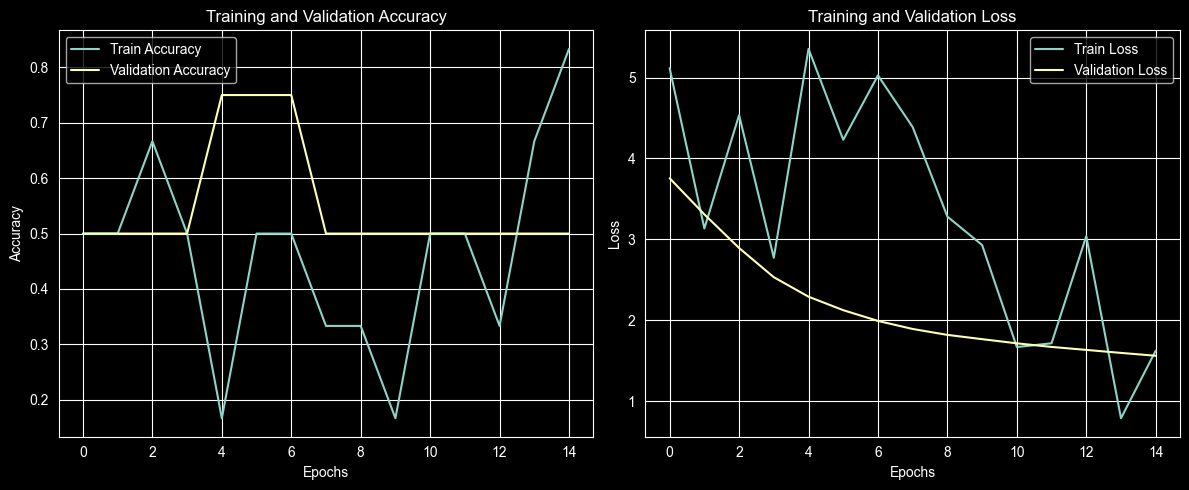

In [7]:
# Visualize the Training Steps

import matplotlib.pyplot as plt
plt.figure(figsize=(12, 5))

# Accuracy (<-)
plt.subplot(1, 2, 1) # plt.subplot(n_filas, n_columnas, índice)
plt.plot(hist.history["accuracy"], label="Train Accuracy")
plt.plot(hist.history["val_accuracy"], label="Validation Accuracy")
plt.title("Training and Validation Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()

# Loss (->)
plt.subplot(1, 2, 2)
plt.plot(hist.history["loss"], label="Train Loss")
plt.plot(hist.history["val_loss"], label="Validation Loss")
plt.title("Training and Validation Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()

plt.tight_layout()
plt.show()




# Test with an input image "cat_or_dog_..."

In [8]:
print("class indices: ", train_data.class_indices)

class_names = {v: k for k, v in train_data.class_indices.items()}
print("CN: ", class_names)

class indices:  {'cats': 0, 'dogs': 1}
CN:  {0: 'cats', 1: 'dogs'}


In [9]:
def predict_image(path, model, class_names):
    img = load_img(path, target_size=(224, 224))
    img_array = img_to_array(img)
    img_array = np.expand_dims(img_array, axis=0)
    img_array = preprocess_input(img_array)

    pred = model.predict(img_array, verbose=0)[0][0]   # un solo número

    # class_names viene de train_data.class_indices
    # normalmente algo como {0: 'cats', 1: 'dogs'}
    if pred >= 0.5:
        pred_idx = 1
        confidence = pred
    else:
        pred_idx = 0
        confidence = 1 - pred

    pred_label = class_names[pred_idx]

    print(f"Archivo: {path}")

    plt.figure(figsize=(4, 4))
    plt.imshow(img)
    plt.axis("off")
    plt.show()

    print(f"Probabilidad clase 1: {pred:.6f}")
    print(f"Predicción: {pred_label.capitalize()} ({confidence:.2%})")
    print("-" * 40)

In [10]:
from sklearn.metrics import confusion_matrix, classification_report

pred_probs = model.predict(test_data, verbose=0).ravel()
pred_classes = (pred_probs >= 0.5).astype(int)
true_classes = test_data.classes

print(confusion_matrix(true_classes, pred_classes))
print(classification_report(true_classes, pred_classes, zero_division=0))

[[1 1]
 [1 1]]
              precision    recall  f1-score   support

           0       0.50      0.50      0.50         2
           1       0.50      0.50      0.50         2

    accuracy                           0.50         4
   macro avg       0.50      0.50      0.50         4
weighted avg       0.50      0.50      0.50         4



Archivo: ./dataset/cat_or_dog_1.jpg


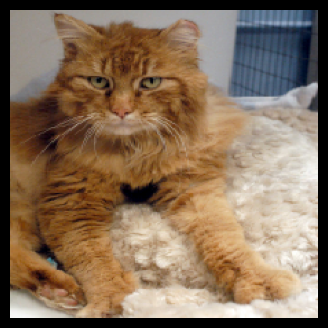

Probabilidad clase 1: 0.000750
Predicción: Cats (99.92%)
----------------------------------------
Archivo: ./dataset/cat_or_dog_2.jpg


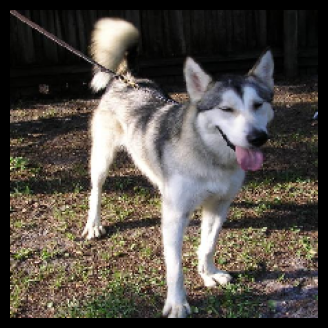

Probabilidad clase 1: 0.000017
Predicción: Cats (100.00%)
----------------------------------------
Archivo: ./dataset/cat_or_dog_3.png


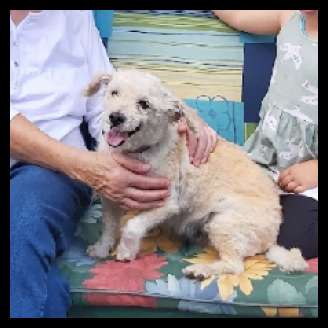

Probabilidad clase 1: 0.978848
Predicción: Dogs (97.88%)
----------------------------------------
Archivo: ./dataset/cat_or_dog_4.png


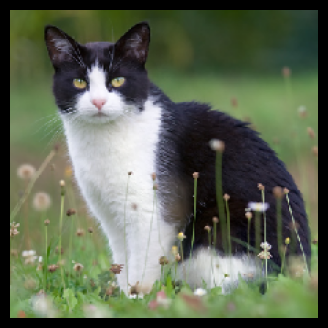

Probabilidad clase 1: 0.096599
Predicción: Cats (90.34%)
----------------------------------------
Archivo: ./dataset/cat_or_dog_5.png


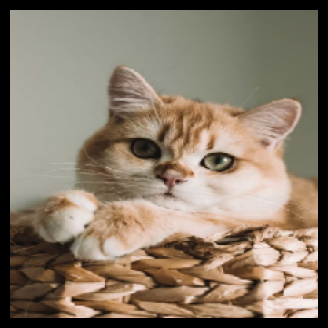

Probabilidad clase 1: 0.000053
Predicción: Cats (99.99%)
----------------------------------------
Archivo: ./dataset/cat_or_dog_6.png


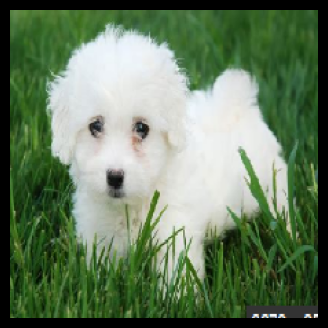

Probabilidad clase 1: 0.785355
Predicción: Dogs (78.54%)
----------------------------------------
Archivo: ./dataset/cat_or_dog_7.png


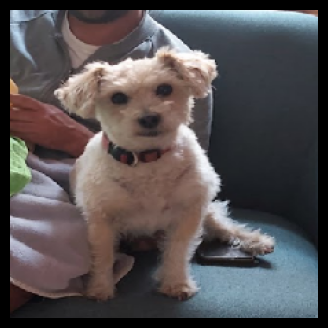

Probabilidad clase 1: 0.991152
Predicción: Dogs (99.12%)
----------------------------------------


In [11]:
predict_image("./dataset/cat_or_dog_1.jpg", model, class_names)
predict_image("./dataset/cat_or_dog_2.jpg", model, class_names)
predict_image("./dataset/cat_or_dog_3.png", model, class_names)
predict_image("./dataset/cat_or_dog_4.png", model, class_names)
predict_image("./dataset/cat_or_dog_5.png", model, class_names)
predict_image("./dataset/cat_or_dog_6.png", model, class_names)
predict_image("./dataset/cat_or_dog_7.png", model, class_names)